In [11]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable


In [17]:
file_path = r"C:\Users\smahm\Desktop\DataProject\Telco customer churn IBM dataset\Telco_customer_churn.csv"
df = pd.read_csv(file_path)

In [19]:
# -----------------------------------------
# Telco Customer Churn - Data Cleaning & KPI Prep
# Python, Pandas, NumPy
# هدف: داده‌ها تمیز و KPIها آماده تحلیل و Power BI
# -----------------------------------------

import pandas as pd
import numpy as np

# 1️⃣ بارگذاری دیتا
file_path = r"C:\Users\smahm\Desktop\DataProject\Telco customer churn IBM dataset\Telco_customer_churn.csv"
df = pd.read_csv(file_path)

# 2️⃣ حذف ستون‌های غیرضروری برای تحلیل KPI
cols_to_drop = ['Count','Lat Long','Latitude','Longitude']  # CustomerID رو نگه می‌داریم برای SQL / join
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# 3️⃣ بررسی missing values
print("Missing values:\n", df.isnull().sum())

# 4️⃣ پر کردن یا مدیریت missing valueها
# مثال: Total Charges ممکنه خالی باشه → با 0 پر می‌کنیم و تبدیل به float
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'].fillna(0, inplace=True)

# 5️⃣ تبدیل categorical به numeric برای تحلیل سریع
# Gender: Male=1, Female=0
df['Gender_num'] = df['Gender'].map({'Male':1,'Female':0})

# Senior Citizen هم numeric هست معمولاً 0/1

# 6️⃣ ساخت KPIهای جدید
# Tenure Category
def tenure_category(months):
    if months <= 12:
        return 'New'
    elif months <= 36:
        return 'Mid'
    else:
        return 'Long-term'

df['Tenure Category'] = df['Tenure Months'].apply(tenure_category)

# Monthly Charges Category
def charges_category(x):
    if x < 35:
        return 'Low'
    elif x < 70:
        return 'Medium'
    else:
        return 'High'

df['Monthly Charges Category'] = df['Monthly Charges'].apply(charges_category)

# Churn Value: 1 = Churned, 0 = Active
df['Churn Value'] = df['Churn Label'].map({'Yes':1,'No':0})

# 7️⃣ بررسی دیتا پس از تمیزکاری
print(df.head())
print(df.info())

# 8️⃣ ذخیره دیتا تمیز شده برای SQL و Power BI
output_path = r"C:\Users\smahm\Desktop\DataProject\Telco customer churn IBM dataset\Telco_customer_churn_cleaned.csv"
df.to_csv(output_path, index=False)
print("✅ دیتا تمیز شده ذخیره شد:", output_path)

Missing values:
 CustomerID              0
Country                 0
State                   0
City                    0
Zip Code                0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64
   CustomerID        Country       State         City  Zip Code  Gender  \
0  3668-QPYBK  United States  California  Los Angeles     90003    Male   
1  9237-HQITU  United States  California  Los Angeles     90005  F

C:\Users\smahm\AppData\Local\Temp\ipykernel_14232\4057113485.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total Charges'].fillna(0, inplace=True)


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned CSV
file_path = r"C:\Users\smahm\Desktop\DataProject\Telco customer churn IBM dataset\Telco_customer_churn_cleaned.csv"
df = pd.read_csv(file_path)

# نمایش ۵ ردیف اول برای اطمینان
print(df.head())

   CustomerID        Country       State         City  Zip Code  Gender  \
0  3668-QPYBK  United States  California  Los Angeles     90003    Male   
1  9237-HQITU  United States  California  Los Angeles     90005  Female   
2  9305-CDSKC  United States  California  Los Angeles     90006  Female   
3  7892-POOKP  United States  California  Los Angeles     90010  Female   
4  0280-XJGEX  United States  California  Los Angeles     90015    Male   

  Senior Citizen Partner Dependents  Tenure Months  ... Monthly Charges  \
0             No      No         No              2  ...           53.85   
1             No      No        Yes              2  ...           70.70   
2             No      No        Yes              8  ...           99.65   
3             No     Yes        Yes             28  ...          104.80   
4             No      No        Yes             49  ...          103.70   

  Total Charges Churn Label Churn Value Churn Score  CLTV  \
0        108.15         Yes          

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


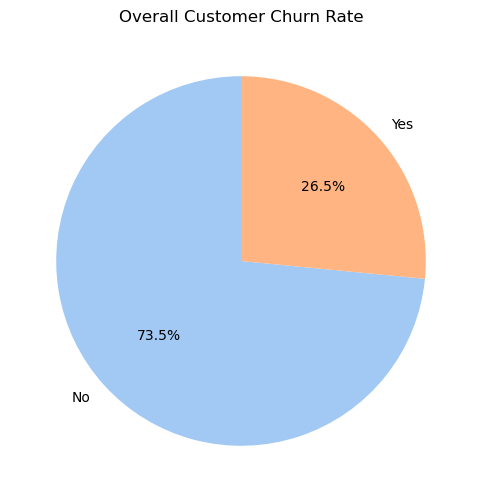

In [5]:
# درصد مشتریان ریزش کرده
churn_rate = df['Churn Label'].value_counts(normalize=True) * 100
print(churn_rate)

# نمودار دایره‌ای
plt.figure(figsize=(6,6))
sns.set_palette("pastel")
plt.pie(churn_rate, labels=churn_rate.index, autopct='%1.1f%%', startangle=90)
plt.title("Overall Customer Churn Rate")
plt.show()

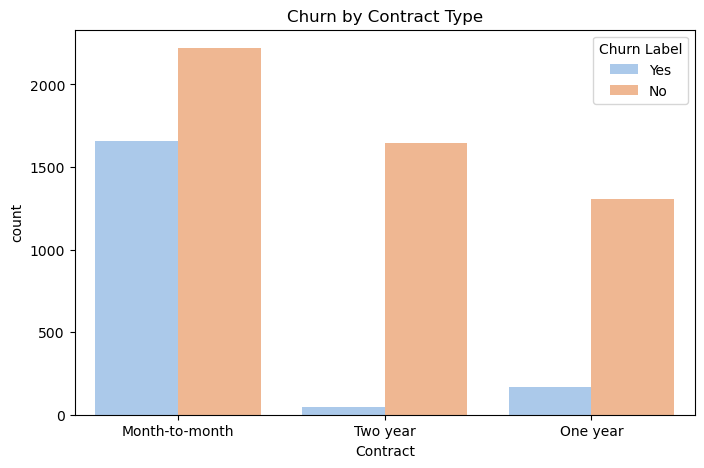

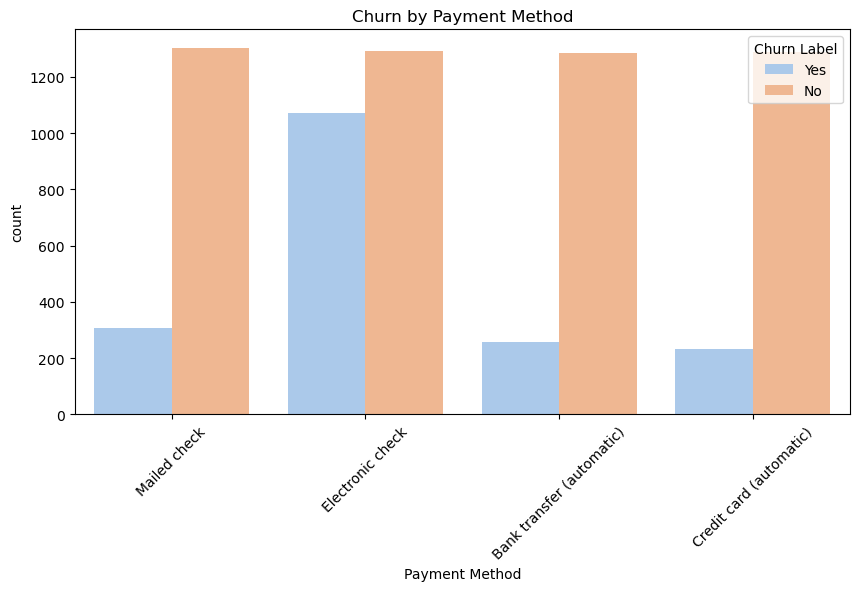

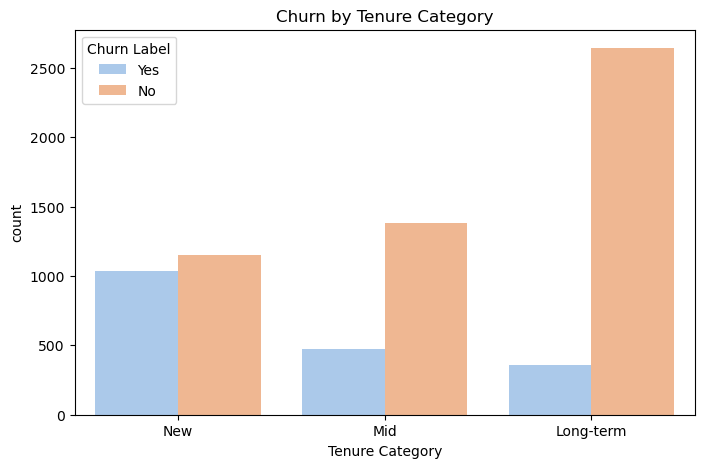

In [9]:
# چرخش مشتری بر اساس قرارداد
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contract', hue='Churn Label')
plt.title("Churn by Contract Type")
plt.show()

# چرخش مشتری بر اساس روش پرداخت
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Payment Method', hue='Churn Label')
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

# چرخش مشتری بر اساس مدت عضویت
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Tenure Category', hue='Churn Label')
plt.title("Churn by Tenure Category")
plt.show()

In [11]:
# میانگین و مقایسه بین مشتریان ریزش کرده و نشده
numeric_cols = ['Monthly Charges', 'Total Charges', 'CLTV']
df.groupby('Churn Label')[numeric_cols].mean()

,Monthly Charges,Total Charges,CLTV
Churn Label,,,
No,61.265124,2549.911442,4490.921337
Yes,74.441332,1531.796094,4149.414660


In [13]:
# ساخت جدول KPI
kpi_table = df.groupby('Churn Label').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Monthly_Charges=('Monthly Charges', 'mean'),
    Avg_Total_Charges=('Total Charges', 'mean'),
    Avg_CLTV=('CLTV', 'mean')
).reset_index()

# اضافه کردن درصد مشتریان
total_customers = df.shape[0]
kpi_table['Customer_Percentage'] = (kpi_table['Customer_Count'] / total_customers) * 100

# نمایش جدول KPI
kpi_table

,Churn Label,Customer_Count,Avg_Monthly_Charges,Avg_Total_Charges,Avg_CLTV,Customer_Percentage
0,No,5174,61.265124,2549.911442,4490.921337,73.463013
1,Yes,1869,74.441332,1531.796094,4149.414660,26.536987


C:\Users\smahm\AppData\Local\Temp\ipykernel_13784\3821041570.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churned_reasons.values, y=churned_reasons.index, palette="viridis")


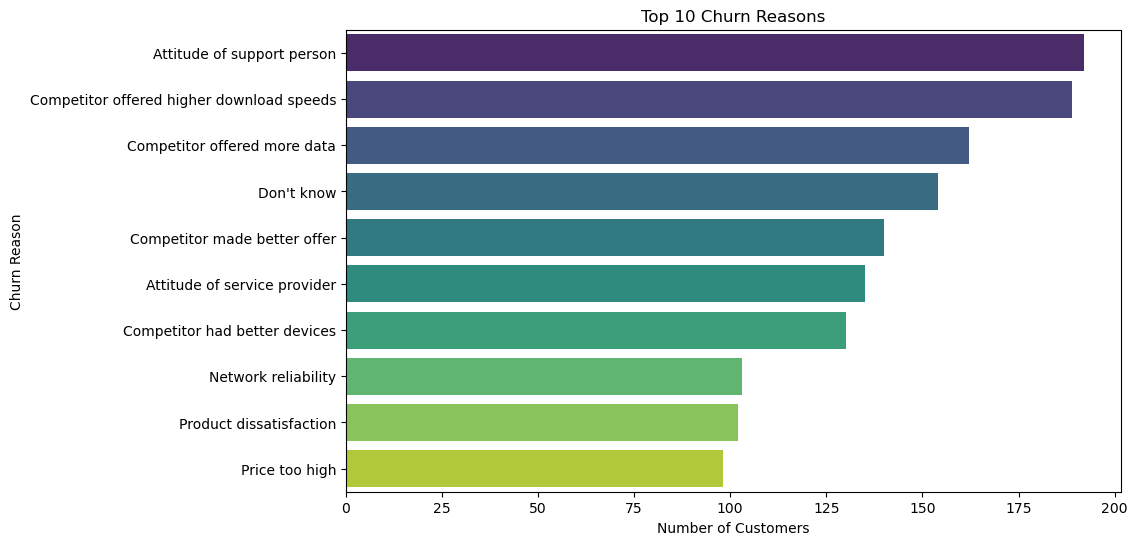

In [15]:
# فقط مشتریان ریزش کرده
churned_reasons = df[df['Churn Label'] == 'Yes']['Churn Reason'].value_counts().head(10)

# نمودار بار
plt.figure(figsize=(10,6))
sns.barplot(x=churned_reasons.values, y=churned_reasons.index, palette="viridis")
plt.title("Top 10 Churn Reasons")
plt.xlabel("Number of Customers")
plt.ylabel("Churn Reason")
plt.show()

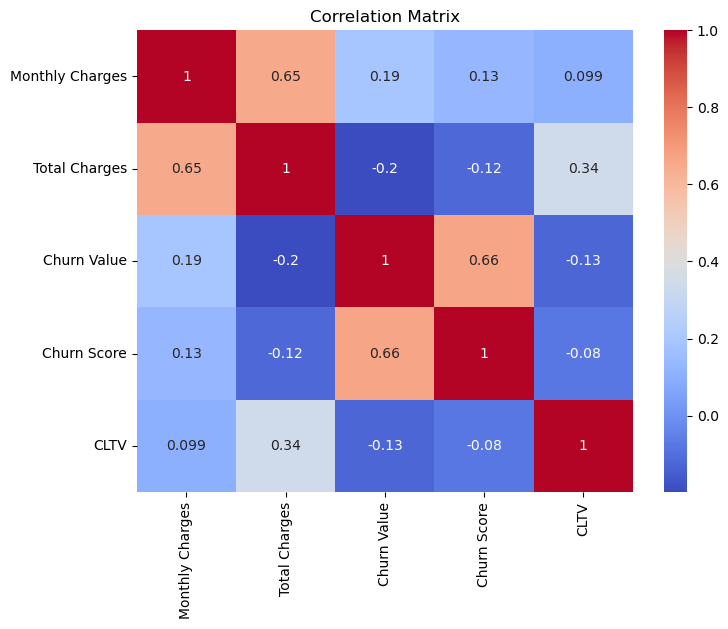

In [17]:
# Heatmap همبستگی عددی
plt.figure(figsize=(8,6))
sns.heatmap(df[['Monthly Charges','Total Charges','Churn Value','Churn Score','CLTV']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ستون هدف
y = df['Churn Value']

# ستون‌های ویژگی (Features)
X = df[['Gender_num', 'Senior Citizen', 'Partner', 'Dependents',
        'Tenure Months', 'Monthly Charges', 'Total Charges',
        'CLTV', 'Tech Support', 'Streaming TV', 'Streaming Movies']]

# تبدیل متغیرهای Yes/No به عدد
yes_no_cols = ['Senior Citizen', 'Partner', 'Dependents', 'Tech Support', 'Streaming TV', 'Streaming Movies']
for col in yes_no_cols:
    X[col] = X[col].replace({'Yes':1, 'No':0})

# استانداردسازی ویژگی‌های عددی
scaler = StandardScaler()
X[['Tenure Months','Monthly Charges','Total Charges','CLTV']] = scaler.fit_transform(X[['Tenure Months','Monthly Charges','Total Charges','CLTV']])

# تقسیم داده‌ها به Train و Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

C:\Users\smahm\AppData\Local\Temp\ipykernel_13784\3597623604.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col] = X[col].replace({'Yes':1, 'No':0})
C:\Users\smahm\AppData\Local\Temp\ipykernel_13784\3597623604.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].replace({'Yes':1, 'No':0})
C:\Users\smahm\AppData\Local\Temp\ipykernel_13784\3597623604.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value in

In [23]:
# ستون‌هایی که Yes/No/No internet service دارند
service_cols = ['Phone Service', 'Multiple Lines', 'Internet Service',
                'Online Security', 'Online Backup', 'Device Protection',
                'Tech Support', 'Streaming TV', 'Streaming Movies']

# جایگزینی مقادیر متنی با عدد
for col in service_cols:
    df[col] = df[col].replace({
        'Yes': 1,
        'No': 0,
        'No phone service': 0,
        'No internet service': 0
    })

# حالا دوباره X و y رو تعریف می‌کنیم
y = df['Churn Value']
X = df[['Gender_num', 'Senior Citizen', 'Partner', 'Dependents',
        'Tenure Months', 'Monthly Charges', 'Total Charges',
        'CLTV', 'Tech Support', 'Streaming TV', 'Streaming Movies']]

# استانداردسازی عددی‌ها
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X[['Tenure Months','Monthly Charges','Total Charges','CLTV']] = scaler.fit_transform(
    X[['Tenure Months','Monthly Charges','Total Charges','CLTV']]
)

# تقسیم Train/Test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

C:\Users\smahm\AppData\Local\Temp\ipykernel_13784\2099232368.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({
C:\Users\smahm\AppData\Local\Temp\ipykernel_13784\2099232368.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[['Tenure Months','Monthly Charges','Total Charges','CLTV']] = scaler.fit_transform(


In [29]:
from sklearn.preprocessing import LabelEncoder

# کپی از دیتافریم برای مدل‌سازی
df_model = df.copy()

# ستون‌های Yes/No و Senior Citizen
binary_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 
               'Multiple Lines', 'Online Security', 'Online Backup', 'Device Protection',
               'Tech Support', 'Streaming TV', 'Streaming Movies', 'Paperless Billing']

le = LabelEncoder()
for col in binary_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# ستون Churn Label به هدف (y)
df_model['Churn Label'] = df_model['Churn Label'].map({'No':0, 'Yes':1})

# ستون‌های چند دسته‌ای
categorical_cols = ['Internet Service', 'Contract', 'Payment Method', 'Tenure Category', 'Monthly Charges Category', 'Churn Reason', 'Country', 'State', 'City']
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# ویژگی‌ها و هدف
X = df_model.drop(['CustomerID', 'Churn Label'], axis=1)
y = df_model['Churn Label']

# تقسیم داده به Train/Test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# مدل پایه
rf = RandomForestClassifier(random_state=42)

# ارزیابی اولیه با Cross-Validation
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross-Validation Accuracy Scores: [0.99822538 1.         1.         1.         1.        ]
Mean CV Accuracy: 0.999645075421473


In [35]:
# محدوده‌های پارامترها
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Grid Search با 5-fold CV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=5, n_jobs=-1, scoring='accuracy', verbose=2)
grid_search.fit(X_train, y_train)

# بهترین پارامترها
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Accuracy: 1.0


In [36]:
# مدل با بهترین پارامترها
best_rf = grid_search.best_estimator_

# پیش‌بینی روی داده تست
y_pred = best_rf.predict(X_test)

# دقت و گزارش
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9992902767920511
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1009
           1       1.00      1.00      1.00       400

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



In [37]:
# مدل با بهترین پارامترها
best_rf = grid_search.best_estimator_

# پیش‌بینی روی داده تست
y_pred = best_rf.predict(X_test)

# دقت و گزارش
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9992902767920511
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1009
           1       1.00      1.00      1.00       400

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



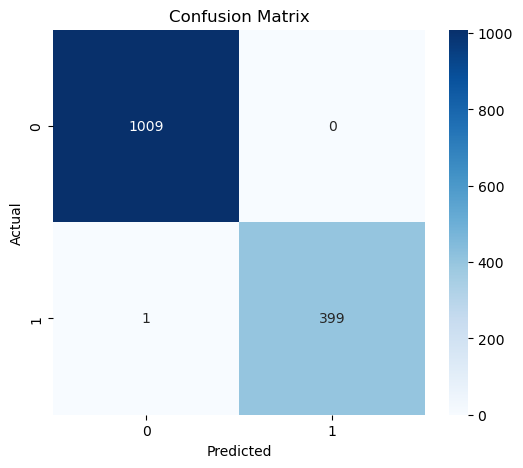

In [38]:
# رسم ماتریس Confusion
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [40]:
# استخراج Feature Importance
importances = best_rf.feature_importances_
features = X_train.columns

# مرتب کردن بر اساس اهمیت
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df.sort_values(by='Importance', ascending=False, inplace=True)

In [46]:
# ستون‌های کلیدی برای داشبورد و KPI
cols_for_dashboard = [
    'CustomerID','Gender','Senior Citizen','Partner','Dependents',
    'Tenure Months','Phone Service','Multiple Lines','Internet Service',
    'Online Security','Online Backup','Device Protection','Tech Support',
    'Streaming TV','Streaming Movies','Contract','Paperless Billing',
    'Payment Method','Monthly Charges','Total Charges','Churn Label','CLTV'
]

df_dashboard = df[cols_for_dashboard]
df_dashboard.to_csv(r"C:\Users\smahm\Desktop\DataProject\Telco_customer_churn_dashboard.csv", index=False)
print("✅ فایل آماده Power BI و SQL ذخیره شد!")

✅ فایل آماده Power BI و SQL ذخیره شد!


In [48]:
# ستون‌های کلیدی برای داشبورد و تحلیل
cols_for_dashboard = [
    'CustomerID','Gender','Senior Citizen','Partner','Dependents',
    'Tenure Months','Phone Service','Multiple Lines','Internet Service',
    'Online Security','Online Backup','Device Protection','Tech Support',
    'Streaming TV','Streaming Movies','Contract','Paperless Billing',
    'Payment Method','Monthly Charges','Total Charges','Churn Label','CLTV'
]

df_dashboard = df[cols_for_dashboard]

# تبدیل مقادیر Yes/No به 1/0
yes_no_cols = ['Senior Citizen','Partner','Dependents','Phone Service',
               'Multiple Lines','Online Security','Online Backup',
               'Device Protection','Tech Support','Streaming TV','Streaming Movies',
               'Paperless Billing','Churn Label']

for col in yes_no_cols:
    df_dashboard[col] = df_dashboard[col].replace({'Yes':1, 'No':0, 'No internet service':0, 'No phone service':0})

# ذخیره فایل CSV برای همه ابزارها
df_dashboard.to_csv(r"C:\Users\smahm\Desktop\DataProject\Telco_customer_churn_dashboard.csv", index=False)
print("✅ دیتا آماده Power BI, SQL و Excel شد")

✅ دیتا آماده Power BI, SQL و Excel شد


C:\Users\smahm\AppData\Local\Temp\ipykernel_13784\3012605950.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_dashboard[col] = df_dashboard[col].replace({'Yes':1, 'No':0, 'No internet service':0, 'No phone service':0})
C:\Users\smahm\AppData\Local\Temp\ipykernel_13784\3012605950.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dashboard[col] = df_dashboard[col].replace({'Yes':1, 'No':0, 'No internet service':0, 'No phone service':0})
